# Azure OpenAI GPT-Image-1: Image Generation Demo

This notebook demonstrates how to generate images using Azure AI Foundry's `gpt-image-1` model via the Azure OpenAI Inference SDK. It securely loads credentials from a `.env` file and showcases prompt-based image creation.

## Prerequisites
- Azure OpenAI resource with the `gpt-image-1` model deployed
- `.env` file in this folder with the following keys:
```
AZURE_API_KEY=<yourkey>
AZURE_OPENAI_ENDPOINT=<yourendpoint>
AZURE_OPENAI_MODEL=gpt-image-1
```

## For the Azure OpenAI GPT-Image-1 (DALL-E 3) model, the available image sizes are:
- "1024x1024" (square)
- "1536x1024" (landscape)
- "1024x1536" (portrait)

In [10]:
# Install required packages
!pip install openai>=1.0.0 python-dotenv pillow matplotlib

In [ ]:
import os
from dotenv import load_dotenv
import openai
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import base64

# Load environment variables from .env file
load_dotenv()

api_key = os.getenv("AZURE_API_KEY")
endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
model_name = os.getenv("AZURE_OPENAI_MODEL", "gpt-image-1")

if not api_key or not endpoint or not model_name:
    raise ValueError("Missing Azure OpenAI credentials or model name in .env file.")

print(f"Endpoint: {endpoint}")
print(f"Model: {model_name}")

In [3]:
# Initialize Azure OpenAI client
client = openai.AzureOpenAI(
    api_key=api_key,
    api_version="2024-02-15-preview",
    azure_endpoint=endpoint
)

In [5]:
def display_image(image, title=None):
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

def process_image_response(response):
    if hasattr(response, 'data') and response.data and len(response.data) > 0:
        data_item = response.data[0]
        if hasattr(data_item, 'url') and data_item.url:
            image_data = requests.get(data_item.url).content
            return Image.open(BytesIO(image_data))
        elif hasattr(data_item, 'b64_json') and data_item.b64_json:
            image_data = base64.b64decode(data_item.b64_json)
            return Image.open(BytesIO(image_data))
    print("No image found in response.")
    return None

## Generate an Image from a Prompt

Generating image with model: gpt-image-1


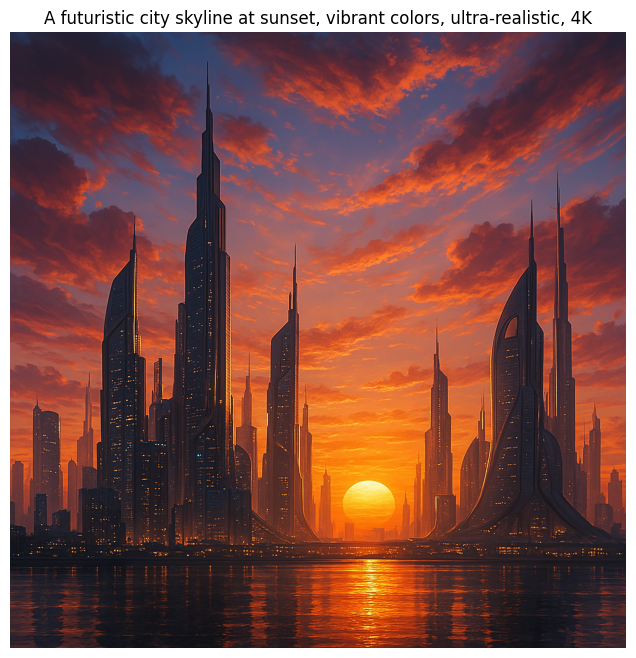

In [6]:
prompt = "A futuristic city skyline at sunset, vibrant colors, ultra-realistic, 4K"

try:
    print(f"Generating image with model: {model_name}")
    response = client.images.generate(
        model=model_name,
        prompt=prompt,
        n=1,
        size="1024x1024"
    )
    image = process_image_response(response)
    if image:
        display_image(image, prompt)
    else:
        print("Image generation failed.")
except Exception as e:
    print(f"Error: {e}")

## Try Your Own Prompt
Change the prompt below and re-run the cell to generate a new image.

Generating image with model: gpt-image-1


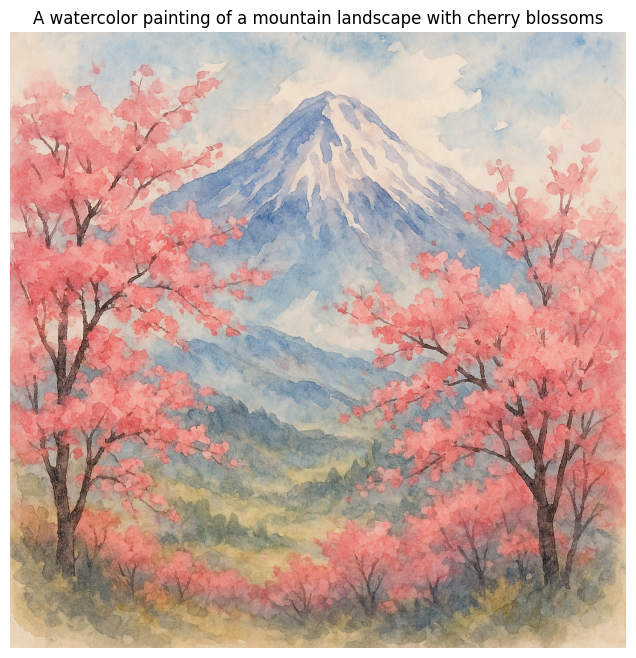

In [17]:
custom_prompt = "A watercolor painting of a mountain landscape with cherry blossoms"

try:
    print(f"Generating image with model: {model_name}")
    response = client.images.generate(
        model=model_name,
        prompt=custom_prompt,
        n=1,
        size="1024x1024"
    )
    image = process_image_response(response)
    if image:
        display_image(image, custom_prompt)
    else:
        print("Image generation failed.")
except Exception as e:
    print(f"Error: {e}")

---

This notebook demonstrates secure, prompt-based image generation using Azure AI Foundry's GPT-Image-1 model and the Azure OpenAI Inference SDK. For best results, experiment with different prompts and styles!